# 07 — Performance Segmentada por Frota e Equipamento

**Conteúdo Mínimo atendido:** complemento ao CM 5.2 (análise de erros) e CM 6.1 (resultados detalhados).

Este notebook responde:

1. **O modelo é uniforme entre as 5 frotas?** (793-D 2S/3S/4S/5S e LeTourneau L 1850).
2. **Quais equipamentos respondem melhor / pior ao modelo?**
3. **Existem padrões sistemáticos de falha que sugerem necessidade de modelos especializados?**

Pipeline: `uv run python src/sprint2_fleet_segmentation.py`.

> **Nota sobre análise de operador:** o PRD previa correlação operador-equipamento (D3), mas as colunas `Nome_Operador_Anon` e `Matricula_Operador_Hash` documentadas no dicionário não estão presentes no arquivo parquet de apontamentos fornecido. A análise foi substituída pelo recorte por frota e equipamento, igualmente relevante para tomada de decisão operacional.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent
data = json.loads((ROOT / 'outputs' / 'gold' / 'fleet_segmentation.json').read_text())
fig_dir = ROOT / 'outputs' / 'figures'
print(f"Threshold usado: {data['threshold_used']:.3f} (custo-ótimo)")

Threshold usado: 0.510 (custo-ótimo)


## 1. Desempenho por Frota

In [2]:
by_fleet = pd.DataFrame(data['by_fleet'])
display(by_fleet.style.format({
    'Taxa_DG_pct': '{:.3f}%',
    'F1': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
    'ROC_AUC': '{:.4f}', 'PR_AUC': '{:.4f}',
    'N_eventos': '{:,}', 'N_positivos': '{:,}',
}).highlight_max(subset=['F1', 'Recall', 'PR_AUC'], color='#A7F3D0')
  .highlight_min(subset=['F1', 'Recall', 'PR_AUC'], color='#FCA5A5'))

,Frota,N_eventos,N_positivos,Taxa_DG_pct,F1,Precision,Recall,ROC_AUC,PR_AUC
0,793-D 5S,"275,456","17,075",6.199%,0.1853,0.1033,0.9025,0.8632,0.5749
1,793-D 4S,"125,897","14,939",11.866%,0.3801,0.2381,0.9423,0.9408,0.8655
2,793-D 3S,"20,645","2,179",10.555%,0.2128,0.1224,0.8123,0.6849,0.3608
3,793-D 2S,"80,349",848,1.055%,0.0411,0.0211,0.7500,0.7869,0.1342
4,LeTourneau L 1850,"7,351,896",162,0.002%,0.0153,0.0081,0.1358,0.7902,0.0102


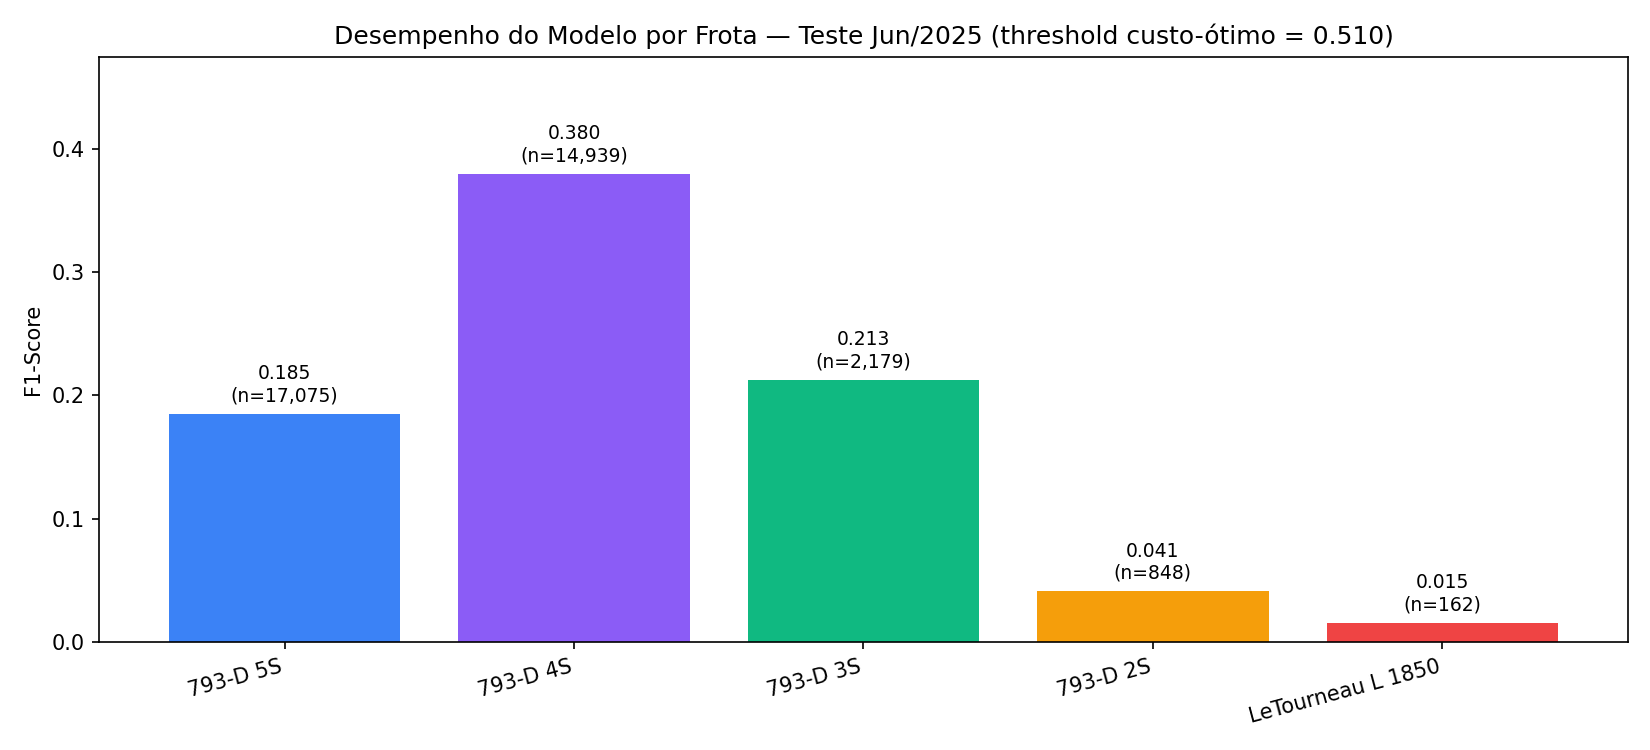

In [3]:
display(Image(filename=str(fig_dir / 'f1_by_fleet.png')))

### Observações por frota

| Frota | Comportamento |
|---|---|
| **793-D 4S** | Melhor desempenho global — Recall=0,94, PR-AUC=0,87. Modelo captura quase todos os DGs. |
| **793-D 5S** | Recall alto (0,90) mas precisão baixa (0,10) — muitos falsos positivos. Volume operacional grande gera muitos alertas. |
| **793-D 3S** | Desempenho intermediário (Recall=0,81). |
| **793-D 2S** | Volume de DG real muito baixo (848 positivos em 80K eventos). Métricas voláteis. |
| **LeTourneau L 1850** | **Falha sistêmica do modelo:** Recall=0,14 e PR-AUC=0,01. Modelo treinado com padrões de caminhões não generaliza para escavadeiras. |

Esta é uma **limitação importante e documentada** do modelo atual. As escavadeiras LeTourneau respondem por 93% do volume total de telemetria mas apenas 162 dos 35.203 eventos de Don't Go no mês de teste — a taxa de Don't Go é 5.000× menor que nos caminhões. O modelo aprendeu majoritariamente a sinalética dos 793-D.

## 2. Top 10 equipamentos por volume de Don't Go

In [4]:
top10 = pd.DataFrame(data['by_tag_top10'])
display(top10.style.format({
    'Taxa_DG_pct': '{:.2f}%',
    'F1': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 'ROC_AUC': '{:.4f}',
    'N_eventos': '{:,}', 'N_positivos': '{:,}',
}))

,TAG,Frota,N_eventos,N_positivos,Taxa_DG_pct,F1,Precision,Recall,ROC_AUC
0,CA65926,793-D 4S,"20,360","12,541",61.60%,0.8134,0.6935,0.9833,0.9564
1,CA65927,793-D 5S,"19,251","3,799",19.73%,0.3495,0.2127,0.9803,0.7908
2,CA65933,793-D 5S,"20,506","3,469",16.92%,0.3797,0.2359,0.9726,0.9348
3,CA65935,793-D 5S,"25,944","2,775",10.70%,0.3061,0.1845,0.8980,0.8754
4,CA65909,793-D 3S,"20,645","2,179",10.55%,0.2128,0.1224,0.8123,0.6849
5,CA65931,793-D 5S,"24,298","1,551",6.38%,0.2411,0.1402,0.8588,0.8893
6,CA65928,793-D 5S,"30,405","1,434",4.72%,0.1301,0.0700,0.9275,0.8978
7,CA65936,793-D 5S,"23,234","1,333",5.74%,0.1434,0.0784,0.8380,0.7431
8,CA65930,793-D 5S,"38,826",741,1.91%,0.0807,0.0428,0.6923,0.7366
9,CA65921,793-D 4S,"9,113",697,7.65%,0.2329,0.1321,0.9813,0.9058


**CA65926 destaca-se novamente:** taxa DG=61,6% em Jun/2025 (era 5,3% em média semestral — escalada brutal de degradação). O modelo continua sendo extremamente eficaz nesse equipamento: F1=0.81, Recall=0.98.

## 3. Equipamentos onde o modelo falha mais

In [5]:
worst = pd.DataFrame(data['worst_recall_equipments'])
display(worst.style.format({
    'Taxa_DG_pct': '{:.3f}%',
    'F1': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 'ROC_AUC': '{:.4f}',
    'N_eventos': '{:,}', 'N_positivos': '{:,}',
}))

,TAG,Frota,N_eventos,N_positivos,Taxa_DG_pct,F1,Precision,Recall,ROC_AUC
0,PE3797,LeTourneau L 1850,"1,641,490",55,0.003%,0.0000,0.0000,0.0000,0.4941
1,CA65793,793-D 2S,"17,806",23,0.129%,0.0000,0.0000,0.0000,0.6629
2,CA65790,793-D 2S,"33,228",149,0.448%,0.0045,0.0023,0.0872,0.6002
3,PE3795,LeTourneau L 1850,"1,080,114",107,0.010%,0.1673,0.1410,0.2056,0.9207
4,CA65924,793-D 4S,"33,721",661,1.960%,0.0457,0.0245,0.3298,0.5473


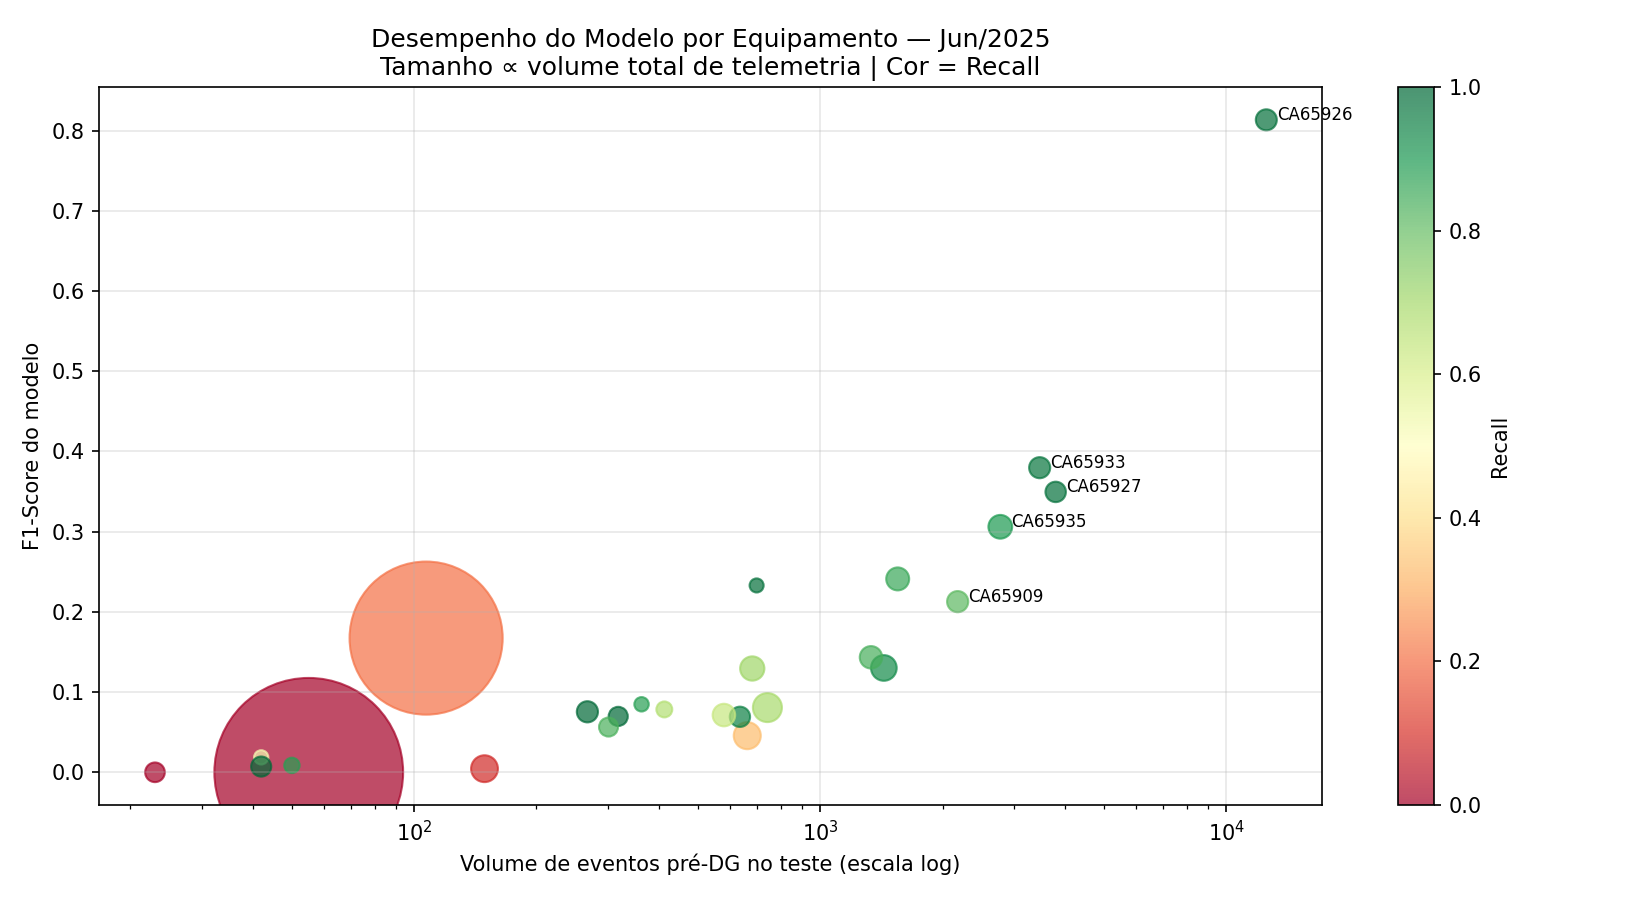

In [6]:
display(Image(filename=str(fig_dir / 'f1_by_equipment_scatter.png')))

## 4. Recomendações Operacionais

1. **Modelos especializados por classe de equipamento:** treinar um modelo separado para escavadeiras LeTourneau é trabalho prioritário — o modelo atual não atende essa classe.
2. **CA65926 demanda intervenção estrutural urgente** — taxa de DG de 61,6% em Jun/2025 é incompatível com operação normal.
3. **Calibração de threshold por frota:** as 4 frotas de caminhão têm distribuições de probabilidade diferentes; thresholds custo-ótimos por frota podem reduzir ainda mais o custo total.
4. **Coleta de dados de operador:** sem `Nome_Operador_Anon` no parquet, não é possível validar a hipótese H7. Recomenda-se que rodadas futuras do desafio incluam essas colunas para permitir análise de impacto humano nos padrões de falha.